In [1]:
from pathlib import Path
import os

def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "Models").exists() and (candidate / "Dataset source").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing Models and Dataset source.")

BASE_DIR = find_project_root(Path.cwd())
MODEL_ID = "kauffinger/xlm-roberta-base-finetuned-enron"
MODEL_CACHE_DIR = BASE_DIR / "local_artifacts" / "huggingface" / "models"
MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("HF_HOME", str(MODEL_CACHE_DIR / "home"))
os.environ.setdefault("HF_HUB_CACHE", str(MODEL_CACHE_DIR / "hub"))
os.environ.setdefault("HF_XET_CACHE", str(MODEL_CACHE_DIR / "xet"))
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer

DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_new_clean.csv"
TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_LENGTH = 512
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 8

df = pd.read_csv(DATASET_PATH)
df = df.dropna(subset=["Category", "Message"]).copy()
df["Category"] = df["Category"].astype(str).str.strip()
df["Message"] = df["Message"].astype(str).str.strip()
df = df[df["Message"] != ""]
messages = df["Message"]
labels = df["Category"]

x_train, x_test, y_train, y_test = train_test_split(
    messages,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=str(MODEL_CACHE_DIR))
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    cache_dir=str(MODEL_CACHE_DIR),
    use_safetensors=True,
)
model.to(DEVICE)
model.eval()

label2id = {str(label).lower(): int(idx) for label, idx in model.config.label2id.items()}
if not {"ham", "spam"}.issubset(label2id):
    label2id = {"ham": 0, "spam": 1}
id2label = {idx: label for label, idx in label2id.items()}

@torch.inference_mode()
def predict_messages(texts):
    predictions = []
    texts = [str(text) for text in texts]
    for start in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[start:start + BATCH_SIZE]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        logits = model(**inputs).logits
        predicted_ids = logits.argmax(dim=-1).detach().cpu().tolist()
        predictions.extend(id2label[int(idx)] for idx in predicted_ids)
    return predictions

train_predictions = predict_messages(x_train)
predictions = predict_messages(x_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, predictions)
report_df = pd.DataFrame(classification_report(y_test, predictions, output_dict=True)).transpose()

print(f"Training sample: {len(x_train)}")
print(f"Test sample: {len(x_test)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

report_df

C:\ProgramData\anaconda3\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\ProgramData\anaconda3\envs\py310\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Training sample: 19369
Test sample: 4843
Training accuracy: 0.7635
Test accuracy: 0.7650


,precision,recall,f1-score,support
ham,0.982176,0.661638,0.790655,3248.000000
spam,0.586064,0.975549,0.732235,1595.000000
accuracy,0.765022,0.765022,0.765022,0.765022
macro avg,0.784120,0.818593,0.761445,4843.000000
weighted avg,0.851720,0.765022,0.771415,4843.000000


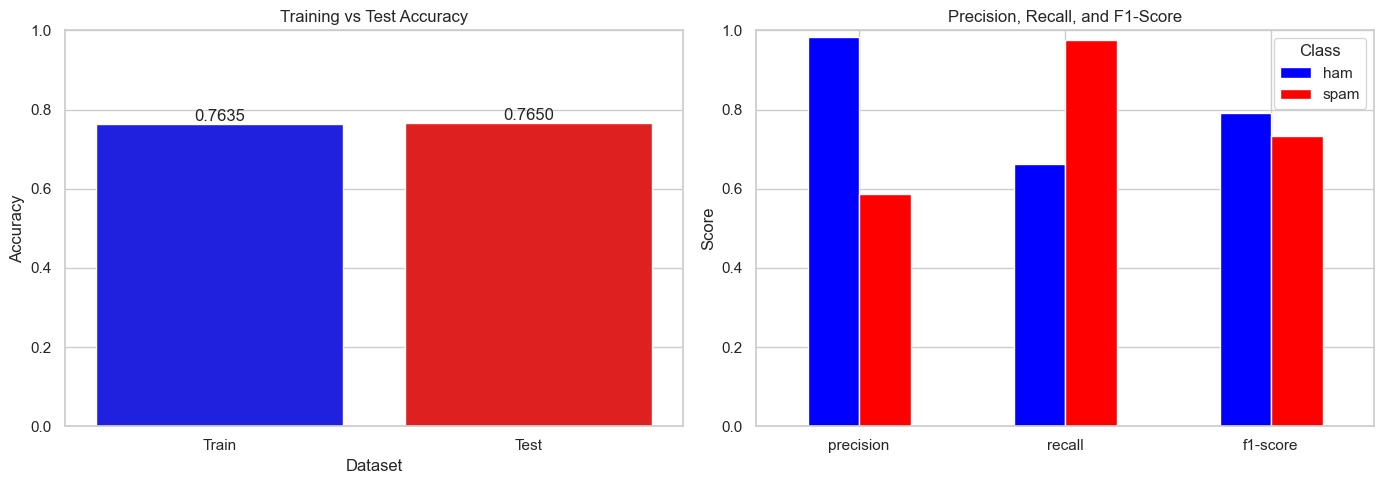

,precision,recall,f1-score,support
ham,0.982176,0.661638,0.790655,3248.000000
spam,0.586064,0.975549,0.732235,1595.000000
accuracy,0.765022,0.765022,0.765022,0.765022
macro avg,0.784120,0.818593,0.761445,4843.000000
weighted avg,0.851720,0.765022,0.771415,4843.000000


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy],
})
sns.barplot(data=accuracy_df, x="Dataset", y="Accuracy", hue="Dataset", palette=["blue", "red"], ax=axes[0], legend=False)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f")

metrics_df = report_df.loc[["ham", "spam"], ["precision", "recall", "f1-score"]].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

report_df

In [3]:
test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"

prediction = predict_messages([test_text])[0]
print(prediction)

spam
